In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zubairdhuddi/student-dataset/student_depression_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers

In [3]:
import os

folder = "/kaggle/input/datasets/zubairdhuddi/student-dataset"

for root, dirs, files in os.walk(folder):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/zubairdhuddi/student-dataset/student_depression_dataset.csv


In [4]:
import pandas as pd 
df=pd.read_csv("/kaggle/input/datasets/zubairdhuddi/student-dataset/student_depression_dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [5]:
df.shape

(27901, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [7]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [8]:
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


In [9]:
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [10]:
df['Depression'].value_counts(normalize=True)

Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64

In [11]:
df = df.drop('id', axis=1, errors='ignore')

In [12]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    print(col)
    print(df[col].unique())
    print()

Gender
['Male' 'Female']

City
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City'
 '3.0' "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad']

Profession
['Student' "'Civil Engineer'" 'Architect' "'UX/UI Designer'"
 "'Digital Marketer'" "'Content Writer'" "'Educational Consultant'"
 'Teacher' 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']

Sleep Duration
["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']

Dietary Habits
['Healthy' 'Moderate' 'Unhealthy' 'Others']

Degree
['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'PhD' "'Class 12'" 'B.Ed' 'LLB'

In [13]:
df['City'].value_counts().head(60)

City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi                     2
Bhavna                     2
City                       2
Harsha                     2
'Less Del

In [14]:
df['Profession'].value_counts()

Profession
Student                     27870
Architect                       8
Teacher                         6
'Digital Marketer'              3
Chef                            2
'Content Writer'                2
Pharmacist                      2
Doctor                          2
'UX/UI Designer'                1
'Civil Engineer'                1
Manager                         1
'Educational Consultant'        1
Lawyer                          1
Entrepreneur                    1
Name: count, dtype: int64

In [15]:
df = df.drop('City', axis=1)

In [16]:
df = df.drop('Profession', axis=1)

In [17]:
df['Financial Stress'].value_counts()

Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
?         3
Name: count, dtype: int64

In [18]:
df.isnull().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [19]:
import numpy as np

df['Financial Stress'] = df['Financial Stress'].replace('?', np.nan)

In [20]:
df['Financial Stress'] = pd.to_numeric(df['Financial Stress'])

In [21]:
df = df.dropna(subset=['Financial Stress'])

In [22]:
df['Financial Stress'].value_counts()

Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
Name: count, dtype: int64

In [23]:
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({
    'No': 0,
    'Yes': 1
})

df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({
    'No': 0,
    'Yes': 1
})

In [24]:
df = pd.get_dummies(
    df,
    columns=['Sleep Duration', 'Dietary Habits', 'Degree'],
    drop_first=True
)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27898 non-null  int64  
 1   Age                                    27898 non-null  float64
 2   Academic Pressure                      27898 non-null  float64
 3   Work Pressure                          27898 non-null  float64
 4   CGPA                                   27898 non-null  float64
 5   Study Satisfaction                     27898 non-null  float64
 6   Job Satisfaction                       27898 non-null  float64
 7   Have you ever had suicidal thoughts ?  27898 non-null  int64  
 8   Work/Study Hours                       27898 non-null  float64
 9   Financial Stress                       27898 non-null  float64
 10  Family History of Mental Illness       27898 non-null  int64  
 11  Depress

In [26]:
X = df.drop('Depression', axis=1)
y = df['Depression']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [29]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

2026-09-22 18:11:03.003398: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [30]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

In [31]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.8091 - loss: 0.4251 - val_binary_accuracy: 0.8452 - val_loss: 0.3596
Epoch 2/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8409 - loss: 0.3729 - val_binary_accuracy: 0.8489 - val_loss: 0.3589
Epoch 3/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8436 - loss: 0.3620 - val_binary_accuracy: 0.8419 - val_loss: 0.3610
Epoch 4/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8458 - loss: 0.3599 - val_binary_accuracy: 0.8461 - val_loss: 0.3599
Epoch 5/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8472 - loss: 0.3595 - val_binary_accuracy: 0.8444 - val_loss: 0.3600
Epoch 6/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8474 - loss: 0.3565 - val_binary_accuracy: 0.8443 - val_loss: 0.3616
Epoch 7/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8480 - loss: 0.3538 - val_binary_accuracy: 0.8443 - val_loss: 0.3587

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,173 (59.27 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,116 (39.52 KB)

In [34]:
history.history.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

<Axes: >

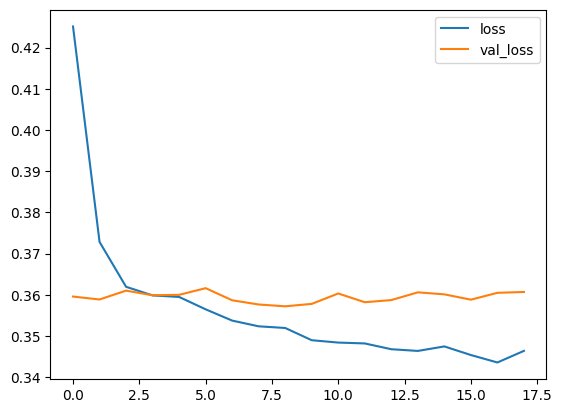

In [35]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df[['loss', 'val_loss']].plot()

<Axes: >

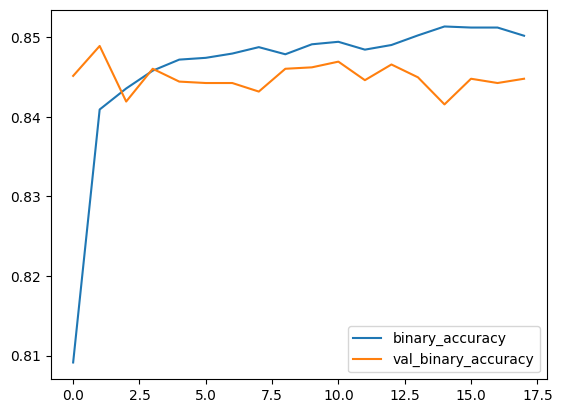

In [36]:
history_df[['binary_accuracy', 'val_binary_accuracy']].plot()

In [37]:
print("Best Validation Accuracy:",
      history_df['val_binary_accuracy'].max())

print("Minimum Validation Loss:",
      history_df['val_loss'].min())

Best Validation Accuracy: 0.8489247560501099
Minimum Validation Loss: 0.35723215341567993


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_valid)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(confusion_matrix(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1816  497]
 [ 378 2889]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.85      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580



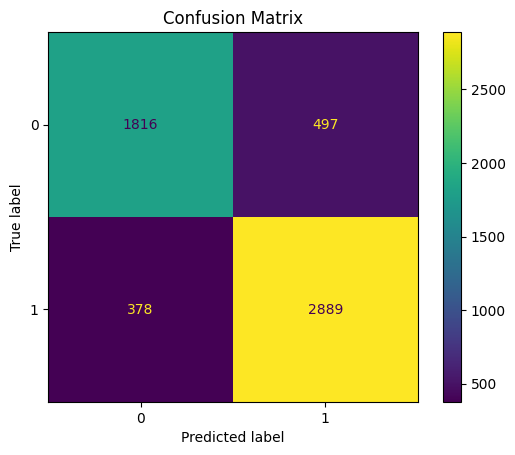

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred)
plt.title("Confusion Matrix")
plt.show()

## Conclusion

In this project, I built a Deep Learning model to predict student depression using a binary classification approach.

The model used:
- Dense neural network layers
- ReLU activation
- Dropout to reduce overfitting
- Sigmoid activation in the output layer
- Adam optimizer
- Binary Crossentropy loss
- Early Stopping

The model achieved approximately 84-85% validation accuracy.

The classification results showed:
- F1-score of 0.81 for class 0
- F1-score of 0.87 for class 1

The model performed reasonably well on both classes, with slightly better performance on class 1.

This project helped me understand how to preprocess data, build and train a neural network, control overfitting, and evaluate a binary classification model.

In [40]:
model.save("student_depression_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [41]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [42]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [43]:
sample = X_valid[0].reshape(1, -1)

prediction = model.predict(sample)

print("Prediction probability:", prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction probability: 0.95173436


In [44]:
if prediction[0][0] >= 0.5:
    print("Predicted Class: 1")
else:
    print("Predicted Class: 0")

print("Actual Class:", y_valid.iloc[0])

Predicted Class: 1
Actual Class: 0


In [45]:
print("Prediction probability:", prediction[0][0])

Prediction probability: 0.95173436


In [46]:
# Predict probabilities for the first 10 validation samples
probs = model.predict(X_valid[:10])

# Convert probabilities to classes
preds = (probs >= 0.5).astype(int).ravel()

# Show results
for i in range(10):
    print(
        f"Sample {i+1}: "
        f"Probability={probs[i][0]:.3f}, "
        f"Predicted={preds[i]}, "
        f"Actual={y_valid.iloc[i]}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Sample 1: Probability=0.952, Predicted=1, Actual=0
Sample 2: Probability=0.973, Predicted=1, Actual=1
Sample 3: Probability=0.005, Predicted=0, Actual=0
Sample 4: Probability=0.170, Predicted=0, Actual=1
Sample 5: Probability=0.996, Predicted=1, Actual=1
Sample 6: Probability=0.939, Predicted=1, Actual=0
Sample 7: Probability=0.142, Predicted=0, Actual=0
Sample 8: Probability=0.993, Predicted=1, Actual=1
Sample 9: Probability=0.957, Predicted=1, Actual=1
Sample 10: Probability=0.026, Predicted=0, Actual=0


In [47]:
for i in range(10):
    if preds[i] != y_valid.iloc[i]:
        print(
            f"Wrong Sample {i+1}: "
            f"Probability={probs[i][0]:.3f}, "
            f"Predicted={preds[i]}, "
            f"Actual={y_valid.iloc[i]}"
        )

Wrong Sample 1: Probability=0.952, Predicted=1, Actual=0
Wrong Sample 4: Probability=0.170, Predicted=0, Actual=1
Wrong Sample 6: Probability=0.939, Predicted=1, Actual=0


## Final Results

The neural network achieved a best validation accuracy of approximately **84.66%** with a minimum validation loss of approximately **0.3587**.

The classification report showed:

- Class 0:
  - Precision: 0.82
  - Recall: 0.79
  - F1-score: 0.81

- Class 1:
  - Precision: 0.86
  - Recall: 0.88
  - F1-score: 0.87

Overall accuracy was approximately **84%**.

The model performed slightly better on class 1 than on class 0.

## Limitations

Although the model achieved good overall performance, some misclassifications still occurred.

For example, some samples received high prediction probabilities but were classified incorrectly. This shows that a high model probability does not guarantee that the prediction is correct.

The dataset also contains self-reported and sensitive mental-health-related information, so this model should be considered an educational machine learning project only.

It should not be used as a medical diagnosis or as a replacement for professional mental health assessment.

## Conclusion

In this project, I built a deep learning model for binary classification using TensorFlow and Keras.

The project included:

- Data exploration
- Data cleaning
- Handling invalid values
- Categorical encoding
- One-hot encoding
- Feature scaling
- Train-validation splitting
- Neural network design
- ReLU activation
- Dropout
- Sigmoid output activation
- Adam optimizer
- Binary crossentropy loss
- Early stopping
- Model evaluation using accuracy, precision, recall, F1-score, and confusion matrix

The final model achieved approximately **84-85% validation accuracy**.

This project helped me apply the main concepts learned in Kaggle's Introduction to Deep Learning course in a complete practical workflow.